### Run this notebook online

[![Open in Colab](https://img.shields.io/badge/Open_in-Colab-F9AB00?logo=googlecolab&logoColor=F9AB00)](https://colab.research.google.com/github/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/files/notebooks/CIFAR10%20UNet%20Diffusion.ipynb)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/kernels/welcome?src=https%3A%2F%2Fgithub.com%2Fhosein-fanai%2FContinual-Learning-with-Diffusion-Vision-Transformers%2Fblob%2Fmain%2Ffiles%2Fnotebooks%2FCIFAR10%2520UNet%2520Diffusion.ipynb)
[![Launch Binder](https://img.shields.io/badge/launch-binder-F5793A?logo=jupyter&logoColor=white)](https://mybinder.org/v2/gh/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/main?urlpath=lab%2Ftree%2Ffiles%2Fnotebooks%2FCIFAR10%20UNet%20Diffusion.ipynb)

- **Google Colab:** open the notebook, select a GPU for training under **Runtime > Change runtime type**, then choose **Run all**.
- **Kaggle:** sign in and import the notebook, enable **Internet**, select a **GPU** accelerator for training, then **Run all**.
- **Binder:** opens a temporary CPU JupyterLab session. Use it to inspect the notebook or run small checks; full training needs more resources.
- **[Studio Lab](https://studiolab.sagemaker.aws/import/github/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/files/notebooks/CIFAR10%20UNet%20Diffusion.ipynb) (existing accounts only):** start a runtime, copy the notebook to your project, select a Python **3.11–3.13** kernel, and set `RUNTIME = "studiolab"` in the first code cell before **Run all**. For CPU, also set `CUDA = False`.

The **first code cell** finds or downloads the repository and prepares TensorFlow **2.20** / Keras **3.11.2** before project imports. If setup requests a restart, restart the kernel and run all again. For another hosted Jupyter service, set `RUNTIME = "hosted"` (`CUDA = False` for CPU or compatible provider-managed CUDA). Locally, select the project TensorFlow kernel.

Launch links open the published GitHub `main` version; publish this notebook and its setup files together before using them. For a notebook that has not been published, upload its `.ipynb` file to Colab or Kaggle instead. GPU availability depends on the provider. Save checkpoints and results before a temporary session ends.

See the [hosted runtime guide](https://github.com/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/files/notebooks/thesis/README.md#hosted-runtimes) for setup and import details.


In [1]:
"""Prepare a notebook checkout and runtime before importing scientific packages.

This canonical first-cell source is copied into maintained notebooks and generated
HPO notebooks. Edit REVISION/RUNTIME/CUDA before execution when needed. Existing
checkouts are reused without fetching; only missing setup code is downloaded.
ROOT is the selected absolute pathlib.Path; RUNTIME_PACKAGES maps package names
to installed version strings. Preparation may clone/install under the selected
policy and changes cwd/import paths through files.notebooks.init.prepare_notebook.
"""
from pathlib import Path
from urllib.request import urlopen


CHECKOUT_NAME = "Continual-Learning-with-Diffusion-Vision-Transformers"
REPOSITORY = f"https://github.com/hosein-fanai/{CHECKOUT_NAME}.git"
REVISION = "main"
RUNTIME = "auto"  # Use "hosted" for another online service, or "local" to verify only.
CUDA = None  # False: CPU or managed CUDA; True: retain CUDA pip dependencies.

_locations = (Path.cwd(), *Path.cwd().parents, Path.cwd() / CHECKOUT_NAME, 
              Path("/kaggle/working") / CHECKOUT_NAME, Path("/content") / CHECKOUT_NAME)
_initializer = next((path / "files" / "notebooks" / "init.py" for path in _locations
                     if (path / "files" / "notebooks" / "init.py").is_file()), None)
_url = f"https://raw.githubusercontent.com/hosein-fanai/{CHECKOUT_NAME}/{REVISION}/files/notebooks/init.py"
_setup = {"__name__": "notebook_setup", "__file__": str(_initializer or _url)}
with (_initializer.open("rb") if _initializer else urlopen(_url, timeout=30)) as _file:
    exec(compile(_file.read(), _setup["__file__"], "exec"), _setup)
ROOT, RUNTIME_PACKAGES = _setup["prepare_notebook"](
    checkout_name=CHECKOUT_NAME, 
    repository=REPOSITORY, 
    revision=REVISION, 
    runtime=RUNTIME, 
    cuda=CUDA
)

Repository ready: /workspace (runtime: local)
Runtime packages ready: Python 3.11.13, TensorFlow 2.20.0, Keras 3.11.2


In [2]:
from common import utils
from common.dataloader import get_dataset


utils.init()

2026-10-08 09:38:42.405503: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Experiment settings


In [3]:
from tensorflow import keras


epochs = 50
val_freq = 5
seed = 42

keras.utils.set_random_seed(seed)

## CIFAR10 data

Keep raw pixel values and labels 0–9; the wrapper handles image preprocessing and CFG label mapping.


In [4]:
from common.dataloader import load_cifar10


x_train, y_train, _, _, x_test, y_test = load_cifar10(
    indices=None, 
    validation_ratio=0.0, 
    verbose=0
)

trainset = get_dataset(
    x_train, 
    y_train.reshape(-1), 
    seed=seed
)
valset = get_dataset(
    x_test, 
    y_test.reshape(-1), 
    shuffle_buffer=0, 
    drop_remainder=False
)

2026-10-08 09:39:14.860493: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1791452354.860614      21 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4055 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060, pci bus id: 0000:01:00.0, compute capability: 7.5


## UNet denoiser

Use three encoder/decoder widths and a 128-channel bottleneck, with time and class conditioning. Train the surrounding diffusion wrapper.


In [ ]:
from diffusion.models.convolution.unet import UNet
from diffusion.models.wrapper.diffusion_model import DiffusionModel


unet = UNet(
    num_classes=10, 
    use_cfg=True, 
    image_size=32, 
    channels=3, 
    widths=(32, 64, 96), 
    block_depth=2, 
    bottleneck_width=128, 
    bottleneck_depth=2, 
    seed=seed
)
model = DiffusionModel(network=unet, seed=seed)

unet.summary()

## Optimizer

Use Adam with cosine decay and mean squared noise-prediction error.


In [6]:
from tensorflow.keras import optimizers


lr_schedule = optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3, 
    decay_steps=epochs * len(trainset)
)

model.compile(
    optimizer=optimizers.Adam(lr_schedule), 
    loss="mse"
)


## Training

Train on the full training split. Validation and sample previews run every `val_freq` epochs.


In [7]:
from tensorflow.keras import callbacks

from diffusion.callbacks.image_generator import ImageGenerator
from common.callbacks.lr_logger import LrLogger


callbacks_list = [
    LrLogger(), 
    callbacks.ProgbarLogger(), 
    ImageGenerator(frequency=val_freq, seed=seed)
]

Epoch 1/50


2026-10-08 09:39:41.424120: I external/local_xla/xla/service/service.cc:163] XLA service 0x71367c003080 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-10-08 09:39:41.424199: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2060, Compute Capability 7.5
2026-10-08 09:39:41.866446: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-10-08 09:39:44.813879: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92600
2026-10-08 09:39:47.453934: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[128,32,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[128,64,32,32]{3,2,1,0}, f32[32,64,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call

390/390 ━━━━━━━━━━━━━━━━━━━━ 78s 91ms/step - noise_loss: 0.0883 - learning_rate: 9.9901e-04
Epoch 2/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 34s 88ms/step - noise_loss: 0.0374 - learning_rate: 9.9606e-04
Epoch 3/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 34s 88ms/step - noise_loss: 0.0348 - learning_rate: 9.9114e-04
Epoch 4/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 89ms/step - noise_loss: 0.0336 - learning_rate: 9.8429e-04
Epoch 5/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - noise_loss: 0.0327

2026-10-08 09:43:11.617756: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[16,32,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,64,32,32]{3,2,1,0}, f32[32,64,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-10-08 09:43:11.683553: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[16,32,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,32,32,32]{3,2,1,0}, f32[32,32,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__c

390/390 ━━━━━━━━━━━━━━━━━━━━ 50s 129ms/step - noise_loss: 0.0327 - val_image_loss: 3.6621 - val_loss: 0.1799 - val_noise_loss: 0.1799 - learning_rate: 9.7553e-04
Steps: 50/50


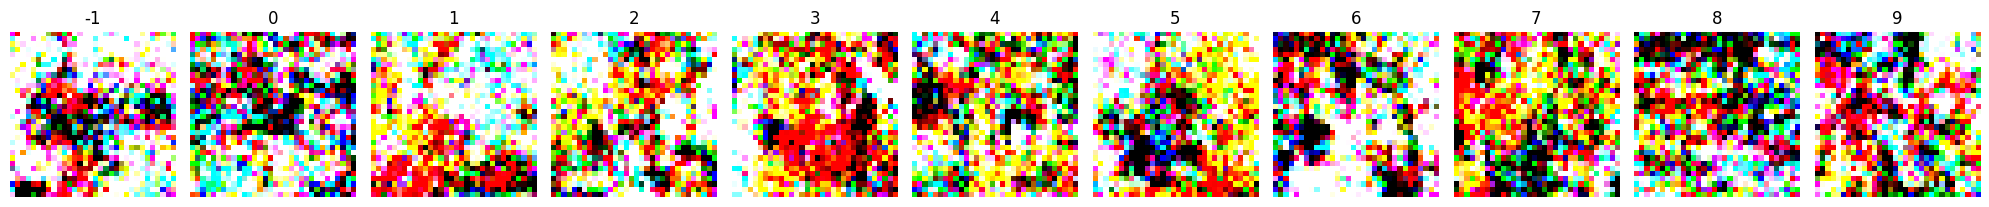

Epoch 6/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 89ms/step - noise_loss: 0.0324 - learning_rate: 9.6489e-04
Epoch 7/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 89ms/step - noise_loss: 0.0319 - learning_rate: 9.5241e-04
Epoch 8/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 89ms/step - noise_loss: 0.0316 - learning_rate: 9.3815e-04
Epoch 9/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - noise_loss: 0.0315 - learning_rate: 9.2216e-04
Epoch 10/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 39s 101ms/step - noise_loss: 0.0311 - val_image_loss: 0.1219 - val_loss: 0.0388 - val_noise_loss: 0.0388 - learning_rate: 9.0451e-04
Steps: 50/50


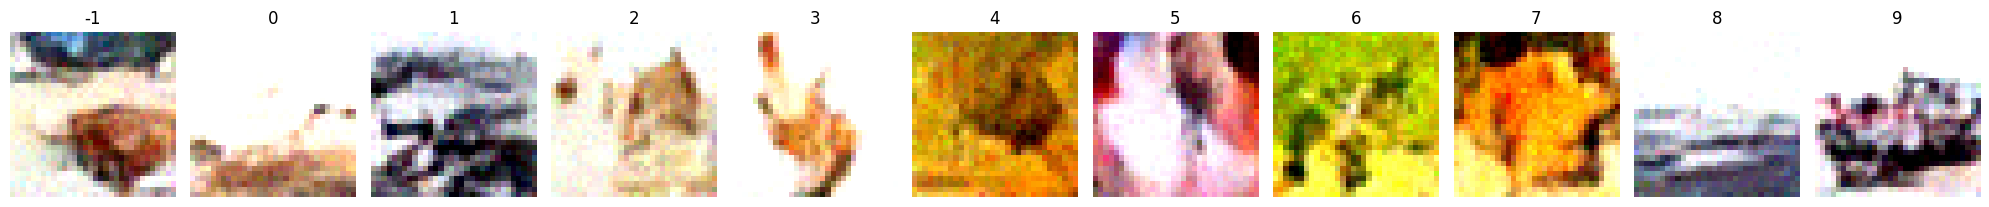

Epoch 11/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - noise_loss: 0.0310 - learning_rate: 8.8526e-04
Epoch 12/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - noise_loss: 0.0306 - learning_rate: 8.6448e-04
Epoch 13/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - noise_loss: 0.0305 - learning_rate: 8.4227e-04
Epoch 14/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - noise_loss: 0.0306 - learning_rate: 8.1871e-04
Epoch 15/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 40s 102ms/step - noise_loss: 0.0304 - val_image_loss: 0.1080 - val_loss: 0.0314 - val_noise_loss: 0.0314 - learning_rate: 7.9389e-04
Steps: 50/50


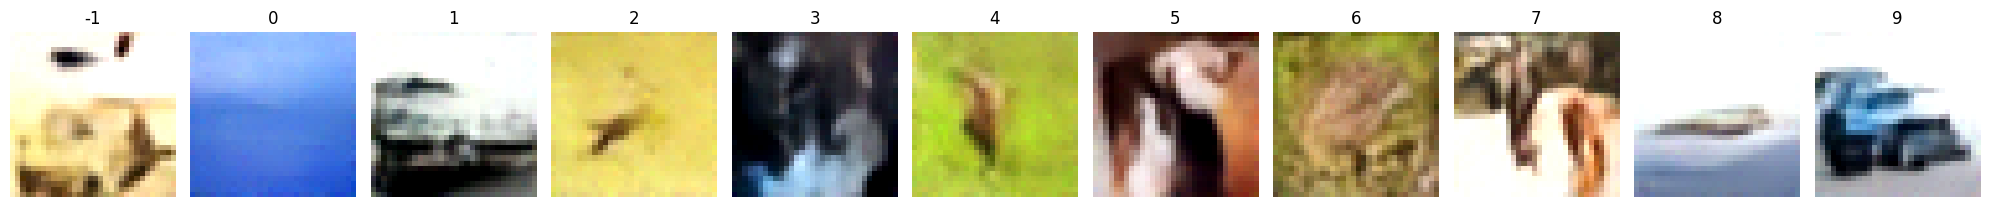

Epoch 16/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - noise_loss: 0.0302 - learning_rate: 7.6791e-04
Epoch 17/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - noise_loss: 0.0302 - learning_rate: 7.4088e-04
Epoch 18/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - noise_loss: 0.0302 - learning_rate: 7.1289e-04
Epoch 19/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 91ms/step - noise_loss: 0.0299 - learning_rate: 6.8406e-04
Epoch 20/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 40s 102ms/step - noise_loss: 0.0298 - val_image_loss: 0.0866 - val_loss: 0.0307 - val_noise_loss: 0.0307 - learning_rate: 6.5451e-04
Steps: 50/50


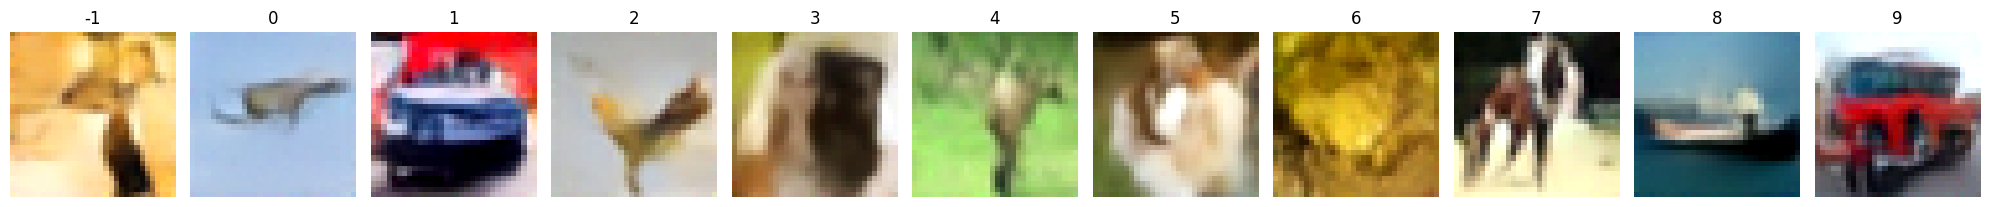

Epoch 21/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - noise_loss: 0.0297 - learning_rate: 6.2435e-04
Epoch 22/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - noise_loss: 0.0296 - learning_rate: 5.9369e-04
Epoch 23/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - noise_loss: 0.0294 - learning_rate: 5.6267e-04
Epoch 24/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - noise_loss: 0.0295 - learning_rate: 5.3140e-04
Epoch 25/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 40s 102ms/step - noise_loss: 0.0293 - val_image_loss: 0.0872 - val_loss: 0.0312 - val_noise_loss: 0.0312 - learning_rate: 5.0000e-04
Steps: 50/50


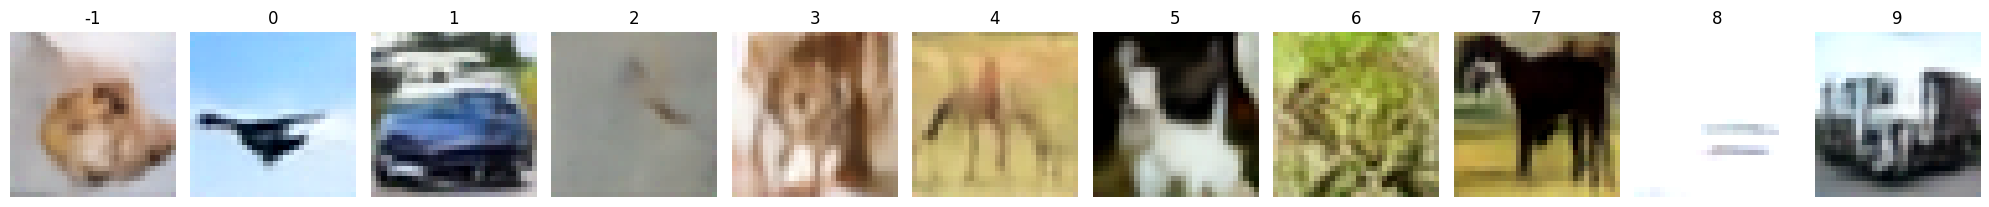

Epoch 26/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - noise_loss: 0.0294 - learning_rate: 4.6860e-04
Epoch 27/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - noise_loss: 0.0295 - learning_rate: 4.3733e-04
Epoch 28/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - noise_loss: 0.0290 - learning_rate: 4.0631e-04
Epoch 29/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - noise_loss: 0.0291 - learning_rate: 3.7566e-04
Epoch 30/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 40s 102ms/step - noise_loss: 0.0290 - val_image_loss: 0.0831 - val_loss: 0.0309 - val_noise_loss: 0.0309 - learning_rate: 3.4549e-04
Steps: 50/50


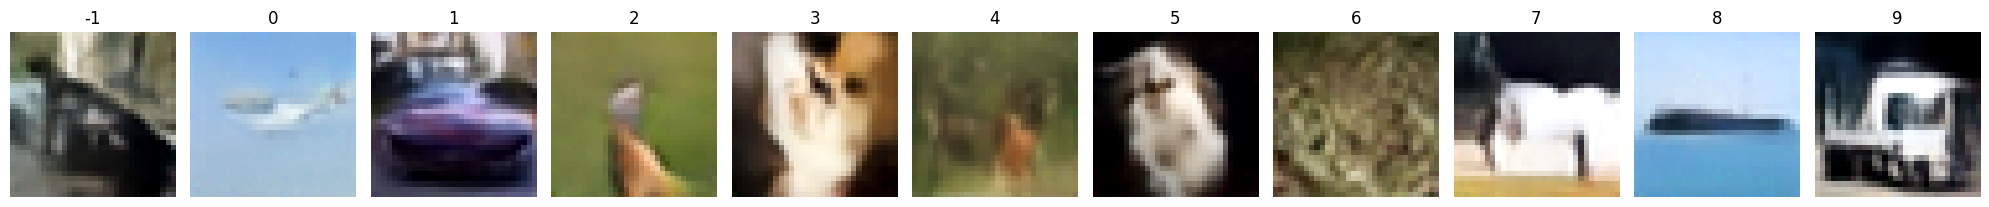

Epoch 31/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - noise_loss: 0.0290 - learning_rate: 3.1594e-04
Epoch 32/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - noise_loss: 0.0290 - learning_rate: 2.8711e-04
Epoch 33/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - noise_loss: 0.0287 - learning_rate: 2.5912e-04
Epoch 34/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - noise_loss: 0.0289 - learning_rate: 2.3209e-04
Epoch 35/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 40s 102ms/step - noise_loss: 0.0288 - val_image_loss: 0.0835 - val_loss: 0.0308 - val_noise_loss: 0.0308 - learning_rate: 2.0611e-04
Steps: 50/50


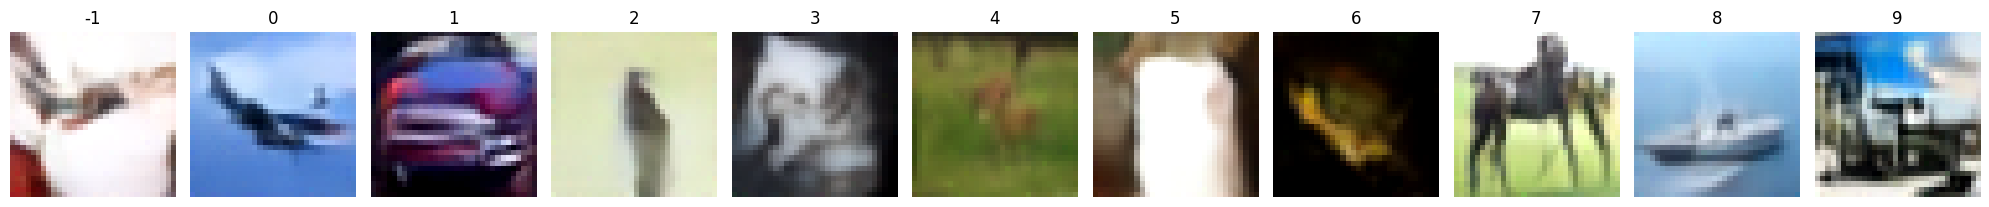

Epoch 36/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - noise_loss: 0.0288 - learning_rate: 1.8129e-04
Epoch 37/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - noise_loss: 0.0287 - learning_rate: 1.5773e-04
Epoch 38/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - noise_loss: 0.0285 - learning_rate: 1.3552e-04
Epoch 39/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - noise_loss: 0.0285 - learning_rate: 1.1474e-04
Epoch 40/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 40s 102ms/step - noise_loss: 0.0286 - val_image_loss: 0.0850 - val_loss: 0.0308 - val_noise_loss: 0.0308 - learning_rate: 9.5491e-05
Steps: 50/50


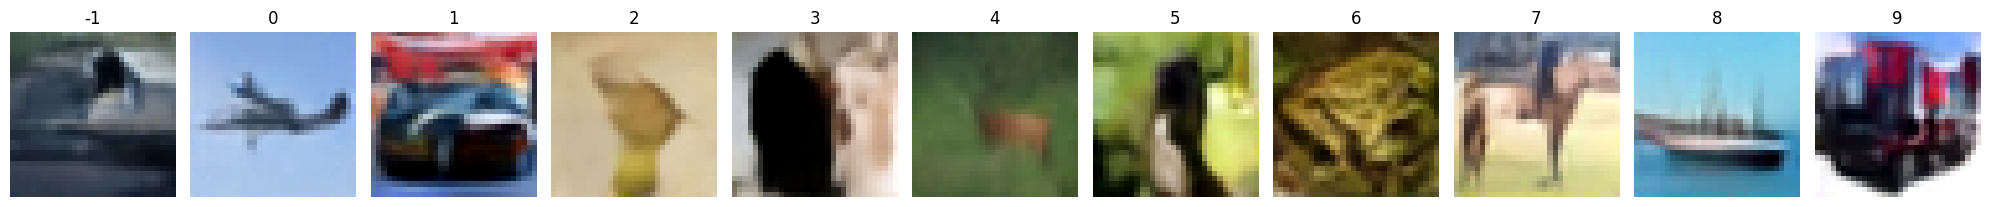

Epoch 41/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - noise_loss: 0.0285 - learning_rate: 7.7836e-05
Epoch 42/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - noise_loss: 0.0283 - learning_rate: 6.1847e-05
Epoch 43/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - noise_loss: 0.0284 - learning_rate: 4.7586e-05
Epoch 44/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - noise_loss: 0.0283 - learning_rate: 3.5112e-05
Epoch 45/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 40s 103ms/step - noise_loss: 0.0282 - val_image_loss: 0.0841 - val_loss: 0.0311 - val_noise_loss: 0.0311 - learning_rate: 2.4472e-05
Steps: 50/50


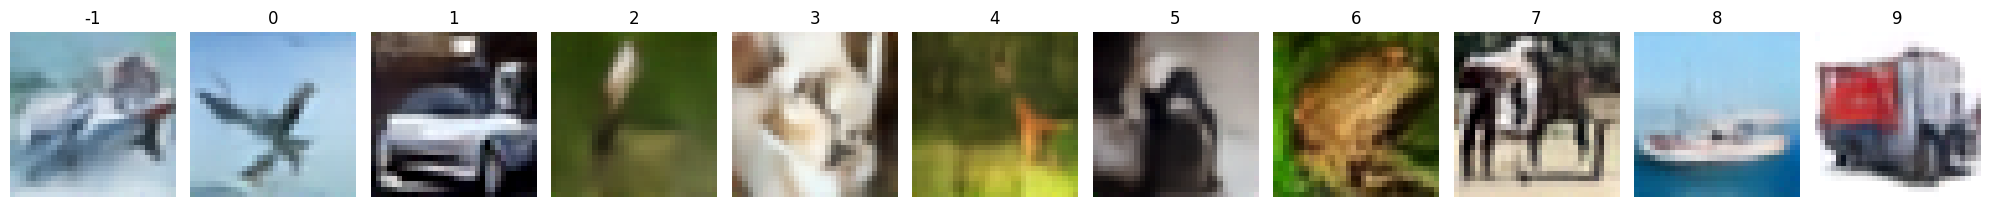

Epoch 46/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 37s 94ms/step - noise_loss: 0.0284 - learning_rate: 1.5708e-05
Epoch 47/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 36s 93ms/step - noise_loss: 0.0283 - learning_rate: 8.8564e-06
Epoch 48/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 36s 92ms/step - noise_loss: 0.0284 - learning_rate: 3.9426e-06
Epoch 49/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 36s 93ms/step - noise_loss: 0.0281 - learning_rate: 9.8664e-07
Epoch 50/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 41s 106ms/step - noise_loss: 0.0282 - val_image_loss: 0.0830 - val_loss: 0.0310 - val_noise_loss: 0.0310 - learning_rate: 0.0000e+00
Steps: 50/50


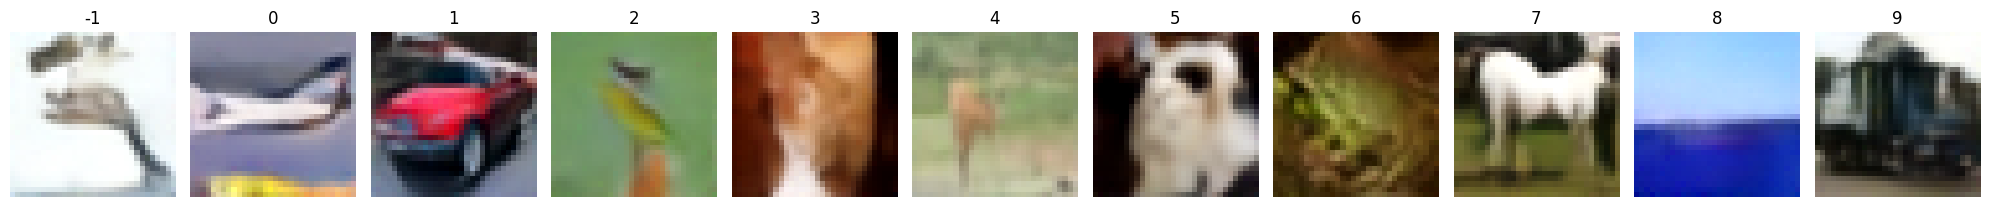

In [8]:
history = model.fit(
    trainset, 
    epochs=epochs, 
    validation_data=valset, 
    callbacks=callbacks_list, 
    validation_freq=val_freq
).history

## Save weights

Save raw and EMA weights under a UNet-specific path. Rerunning this cell replaces this notebook's checkpoint.


In [9]:
model.save_weights("./files/models/CIFAR10 UNet Diffusion/model.weights.h5")

## Evaluate EMA and raw networks

Report diffusion losses for both networks on the same monitoring split.


In [10]:
model.evaluate(valset, network_name="ema")

79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - image_loss: 0.0822 - loss: 0.0316 - noise_loss: 0.0316


[<tf.Tensor: shape=(), dtype=float32, numpy=0.031625598669052124>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.031625598669052124>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.08220803737640381>]

In [11]:
model.evaluate(valset, network_name="raw")

79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 122ms/step - image_loss: 0.0840 - loss: 0.0312 - noise_loss: 0.0312


[<tf.Tensor: shape=(), dtype=float32, numpy=0.03118816763162613>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.03118816763162613>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.08404839783906937>]

## Class-conditional samples

Compare 1,000 stochastic steps, 1,000 deterministic steps, and 50 deterministic steps at guidance scales 3 and 4 using the EMA network. The first image is the null condition, followed by the ten classes. Explicit sampling condition IDs are 1–10; 0 is null. The wrapper already maps images to external pixel values. Sampling stream counters advance between calls even with a fixed seed; these grids are illustrative comparisons, not paired-noise measurements.


Steps: 1000/1000


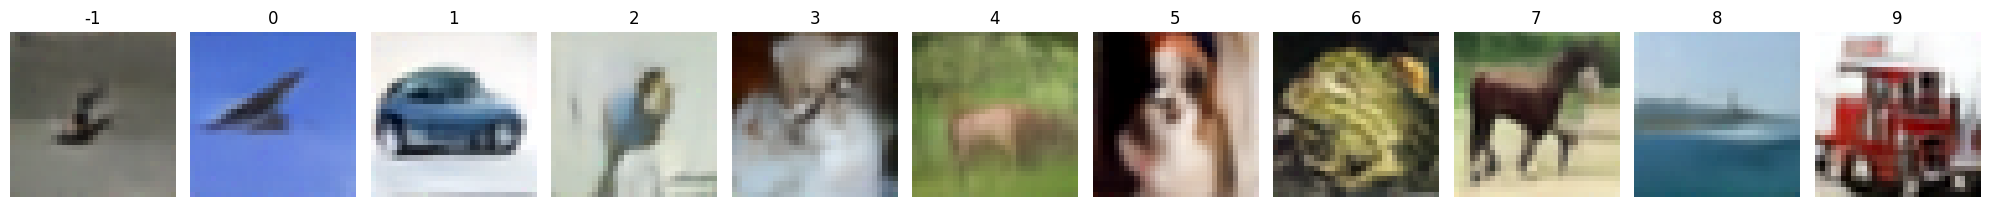

In [12]:
from common.utils import plot_images


imgs = model.sample(
    add_null_label=True, 
    scale=3.0, 
    eta=1.0, 
    steps=1000, 
    network_name="ema", 
    verbose=True, 
    seed=seed
)
plot_images(imgs, has_null_label=True)

Steps: 1000/1000


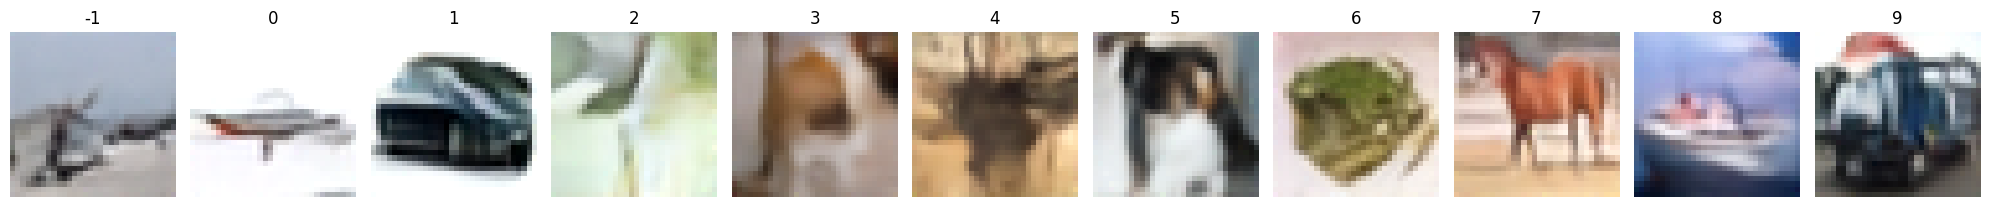

In [13]:
imgs = model.sample(
    add_null_label=True, 
    scale=3.0, 
    eta=0.0, 
    steps=1000, 
    network_name="ema", 
    verbose=True, 
    seed=seed
)
plot_images(imgs, has_null_label=True)

Steps: 50/50


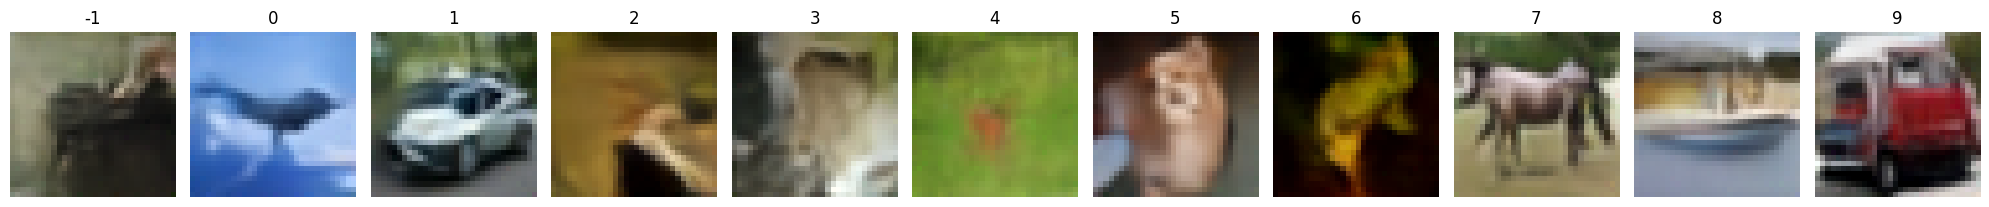

In [14]:
imgs = model.sample(
    add_null_label=True, 
    scale=3.0, 
    eta=0.0, 
    steps=50, 
    network_name="ema", 
    verbose=True, 
    seed=seed
)
plot_images(imgs, has_null_label=True)

Steps: 50/50


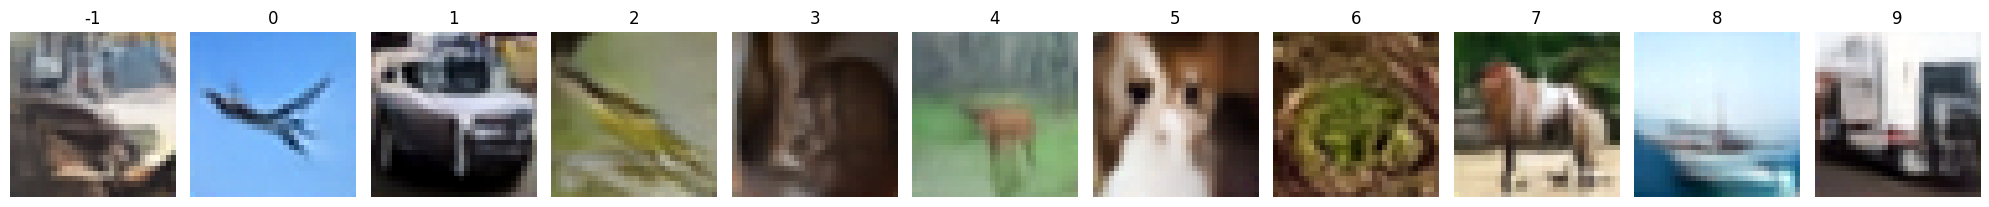

In [15]:
imgs = model.sample(
    add_null_label=True, 
    scale=4.0, 
    eta=0.0, 
    steps=50, 
    network_name="ema", 
    verbose=True, 
    seed=seed
)
plot_images(imgs, has_null_label=True)

## Training history

Keep all recorded metrics, including validation noise loss. The second plot starts at epoch index 5, matching the DiT reference.


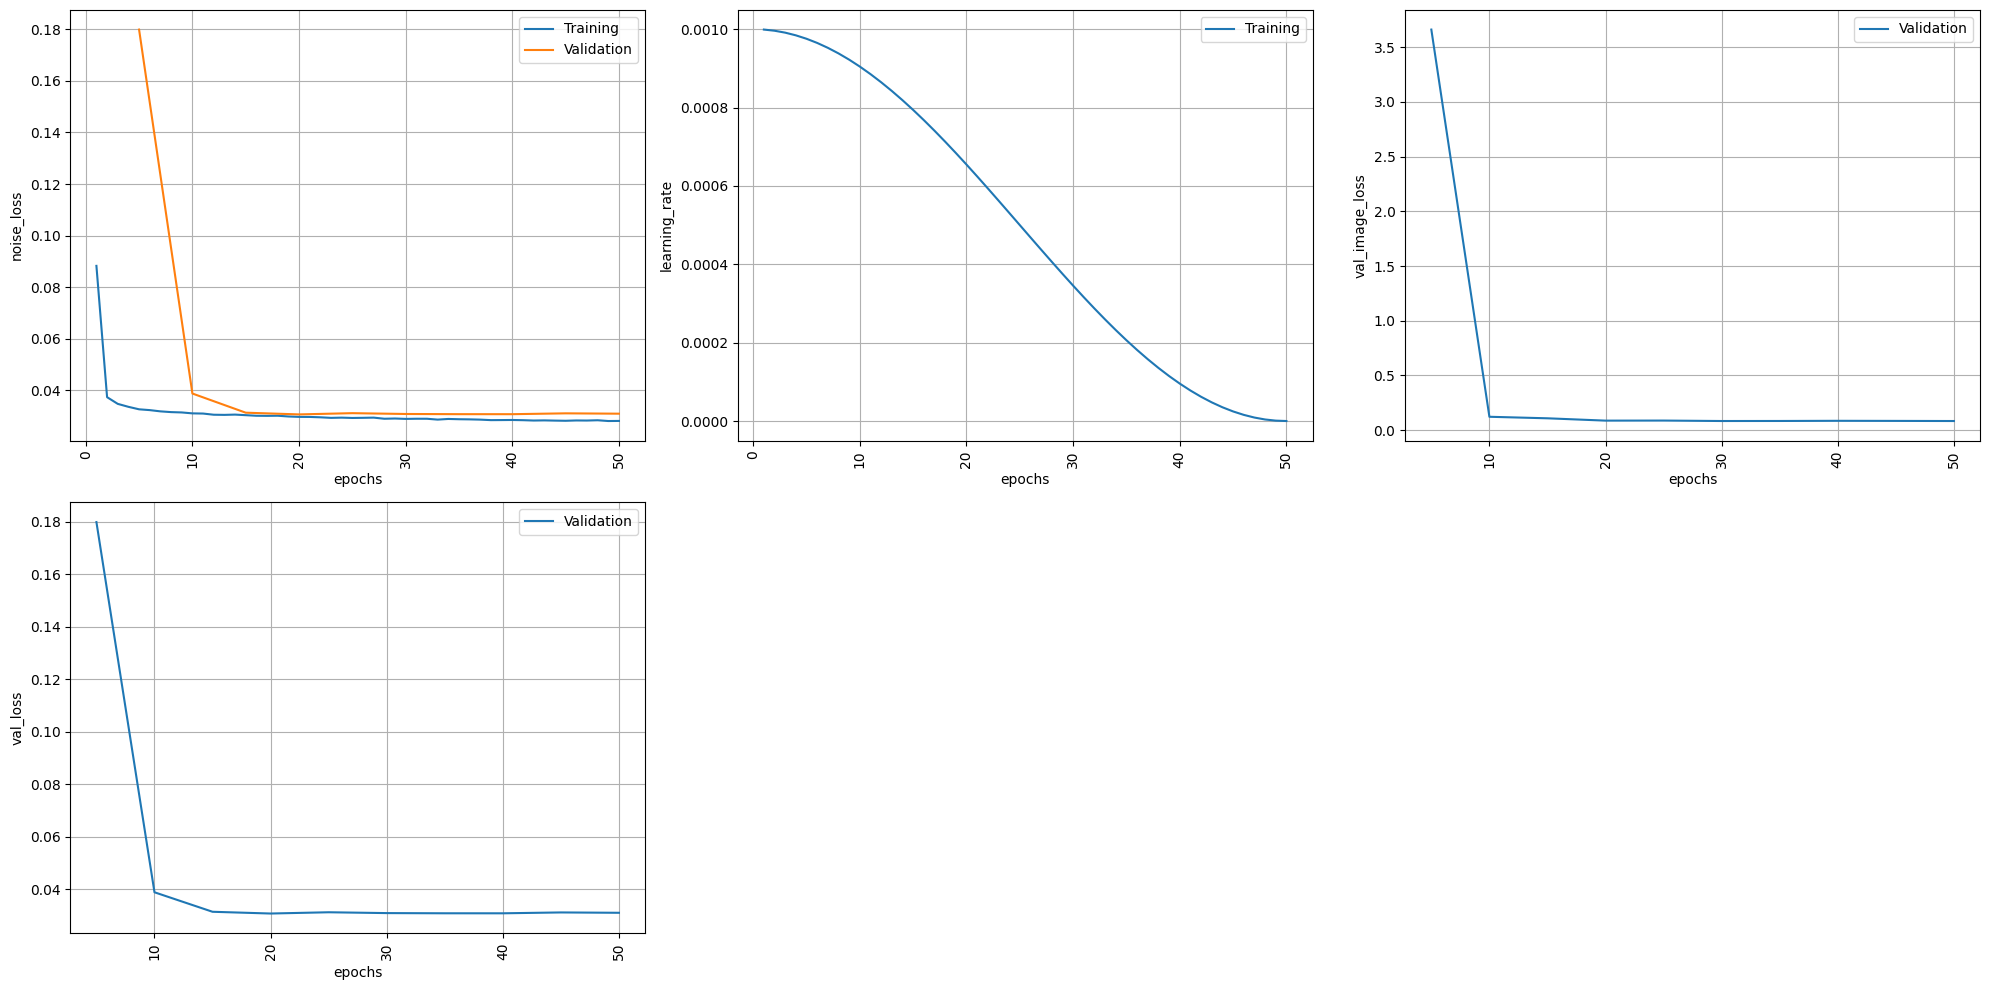

In [16]:
from common.utils import plot_history


plot_history(history, show_all_x_ticks=False, validation_freq=val_freq)

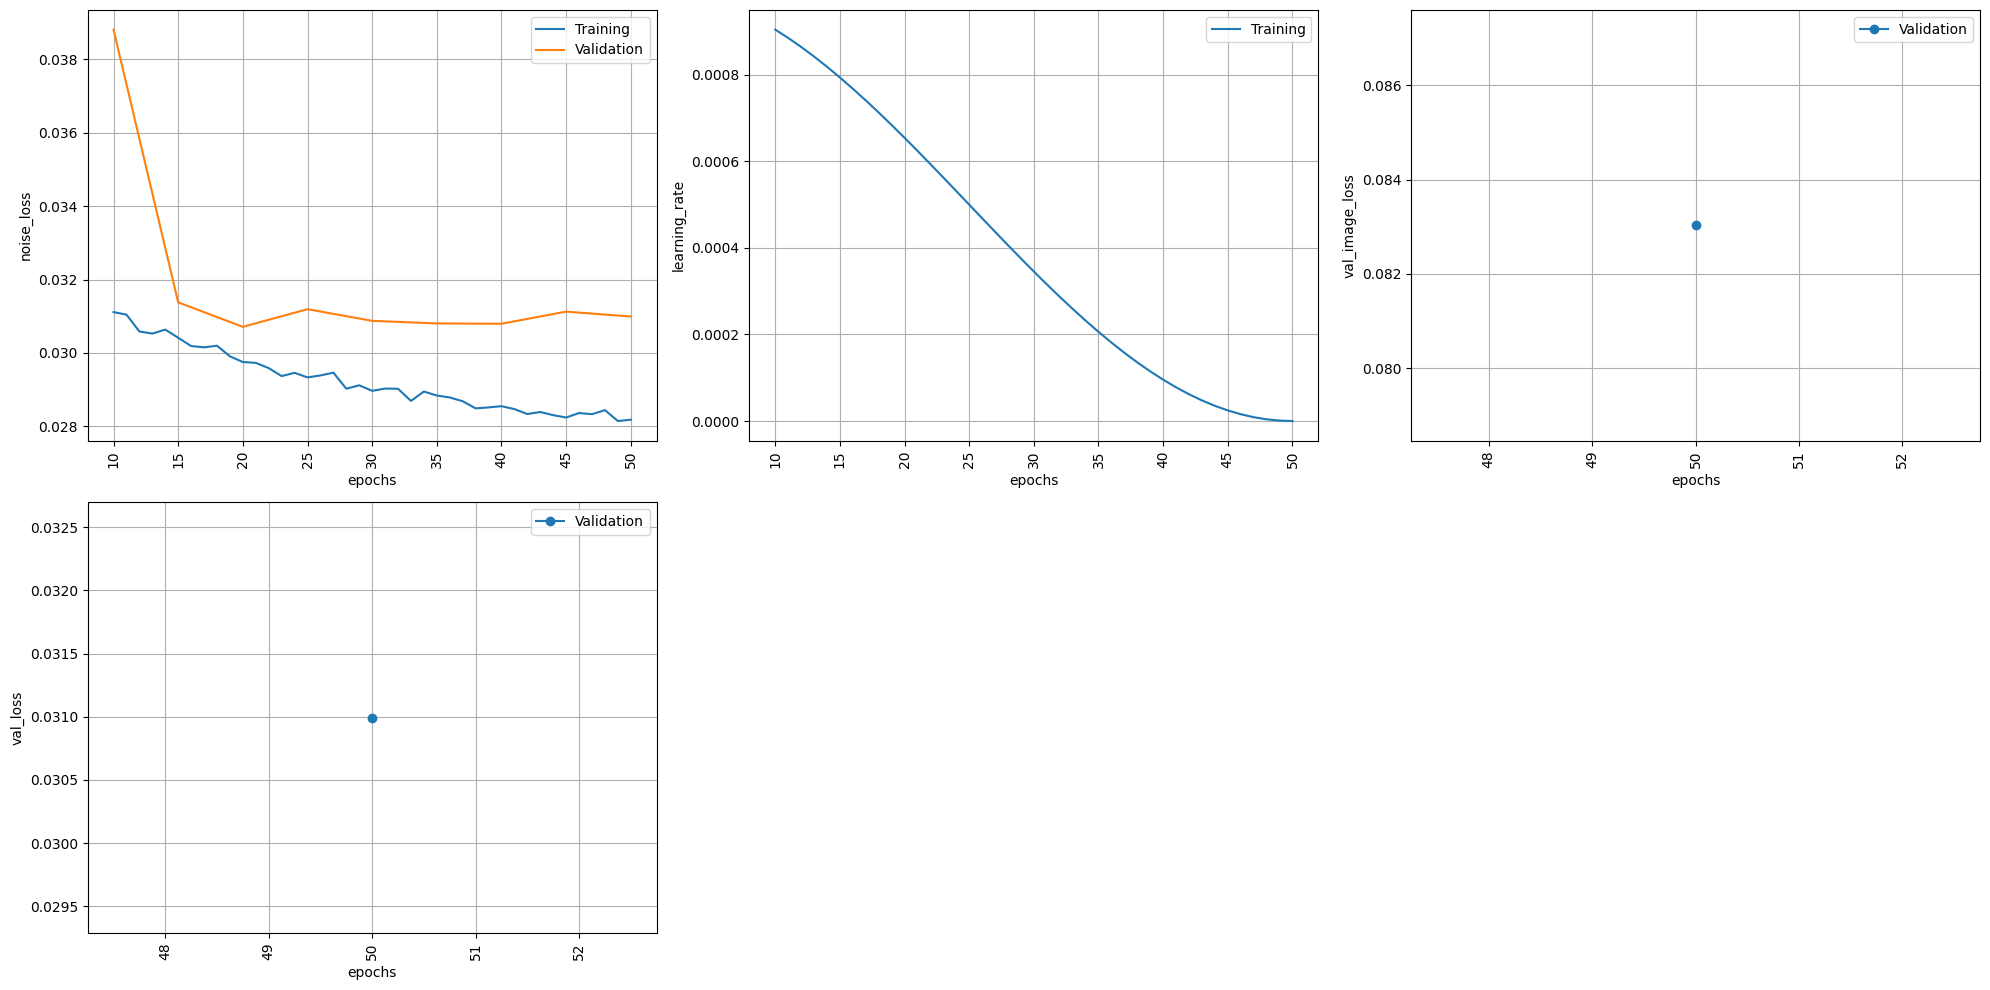

In [17]:
plot_history(history, show_all_x_ticks=False, range_=(9, None), validation_freq=val_freq)